#  McDonald's Menu Nutrition Analysis

In [1]:
#import and setup
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import math

# Configure plotting settings
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
sns.set_palette("husl")
warnings.filterwarnings('ignore')

## Data load and initial exploration

In [2]:
#load data
df = pd.read_csv("/kaggle/input/nutrition-facts/menu.csv")
# Display basic information about the dataset
print("\n🔍 Dataset Overview:")
print(f"Dataset Shape: {df.shape}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

# Check for missing values
print("\n🔍 Missing Values Check:")
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print("✅ No missing values detected!")
else:
    print(missing_values[missing_values > 0])

# Display data types
print("\n🔍 Data Types:")
print(df.dtypes)

# Display first few rows
print("\n🔍 First 5 Rows:")
print(df.head())


🔍 Dataset Overview:
Dataset Shape: (260, 24)
Memory Usage: 100.26 KB

🔍 Missing Values Check:
✅ No missing values detected!

🔍 Data Types:
Category                          object
Item                              object
Serving Size                      object
Calories                           int64
Calories from Fat                  int64
Total Fat                        float64
Total Fat (% Daily Value)          int64
Saturated Fat                    float64
Saturated Fat (% Daily Value)      int64
Trans Fat                        float64
Cholesterol                        int64
Cholesterol (% Daily Value)        int64
Sodium                             int64
Sodium (% Daily Value)             int64
Carbohydrates                      int64
Carbohydrates (% Daily Value)      int64
Dietary Fiber                      int64
Dietary Fiber (% Daily Value)      int64
Sugars                             int64
Protein                            int64
Vitamin A (% Daily Value)          int64

## Exploratory data analysis

In [3]:
# Basic statistics
print("\n📊 Descriptive Statistics:")
print(df.describe())


📊 Descriptive Statistics:
          Calories  Calories from Fat   Total Fat  Total Fat (% Daily Value)  \
count   260.000000         260.000000  260.000000                 260.000000   
mean    368.269231         127.096154   14.165385                  21.815385   
std     240.269886         127.875914   14.205998                  21.885199   
min       0.000000           0.000000    0.000000                   0.000000   
25%     210.000000          20.000000    2.375000                   3.750000   
50%     340.000000         100.000000   11.000000                  17.000000   
75%     500.000000         200.000000   22.250000                  35.000000   
max    1880.000000        1060.000000  118.000000                 182.000000   

       Saturated Fat  Saturated Fat (% Daily Value)   Trans Fat  Cholesterol  \
count     260.000000                     260.000000  260.000000   260.000000   
mean        6.007692                      29.965385    0.203846    54.942308   
std         

In [4]:
df

,Category,Item,Serving Size,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,...,Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
0,Breakfast,Egg McMuffin,4.8 oz (136 g),300,120,13.0,20,5.0,25,0.0,...,31,10,4,17,3,17,10,0,25,15
1,Breakfast,Egg White Delight,4.8 oz (135 g),250,70,8.0,12,3.0,15,0.0,...,30,10,4,17,3,18,6,0,25,8
2,Breakfast,Sausage McMuffin,3.9 oz (111 g),370,200,23.0,35,8.0,42,0.0,...,29,10,4,17,2,14,8,0,25,10
3,Breakfast,Sausage McMuffin with Egg,5.7 oz (161 g),450,250,28.0,43,10.0,52,0.0,...,30,10,4,17,2,21,15,0,30,15
4,Breakfast,Sausage McMuffin with Egg Whites,5.7 oz (161 g),400,210,23.0,35,8.0,42,0.0,...,30,10,4,17,2,21,6,0,25,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,Smoothies & Shakes,McFlurry with Oreo Cookies (Small),10.1 oz (285 g),510,150,17.0,26,9.0,44,0.5,...,80,27,1,4,64,12,15,0,40,8
256,Smoothies & Shakes,McFlurry with Oreo Cookies (Medium),13.4 oz (381 g),690,200,23.0,35,12.0,58,1.0,...,106,35,1,5,85,15,20,0,50,10
257,Smoothies & Shakes,McFlurry with Oreo Cookies (Snack),6.7 oz (190 g),340,100,11.0,17,6.0,29,0.0,...,53,18,1,2,43,8,10,0,25,6
258,Smoothies & Shakes,McFlurry with Reese's Peanut Butter Cups (Medium),14.2 oz (403 g),810,290,32.0,50,15.0,76,1.0,...,114,38,2,9,103,21,20,0,60,6


In [5]:
category_counts = df['Category'].value_counts()
print("Menu Categories:")
print("===" *10)
print(category_counts)

Menu Categories:
Category
Coffee & Tea          95
Breakfast             42
Smoothies & Shakes    28
Chicken & Fish        27
Beverages             27
Beef & Pork           15
Snacks & Sides        13
Desserts               7
Salads                 6
Name: count, dtype: int64


## Distribution analysis

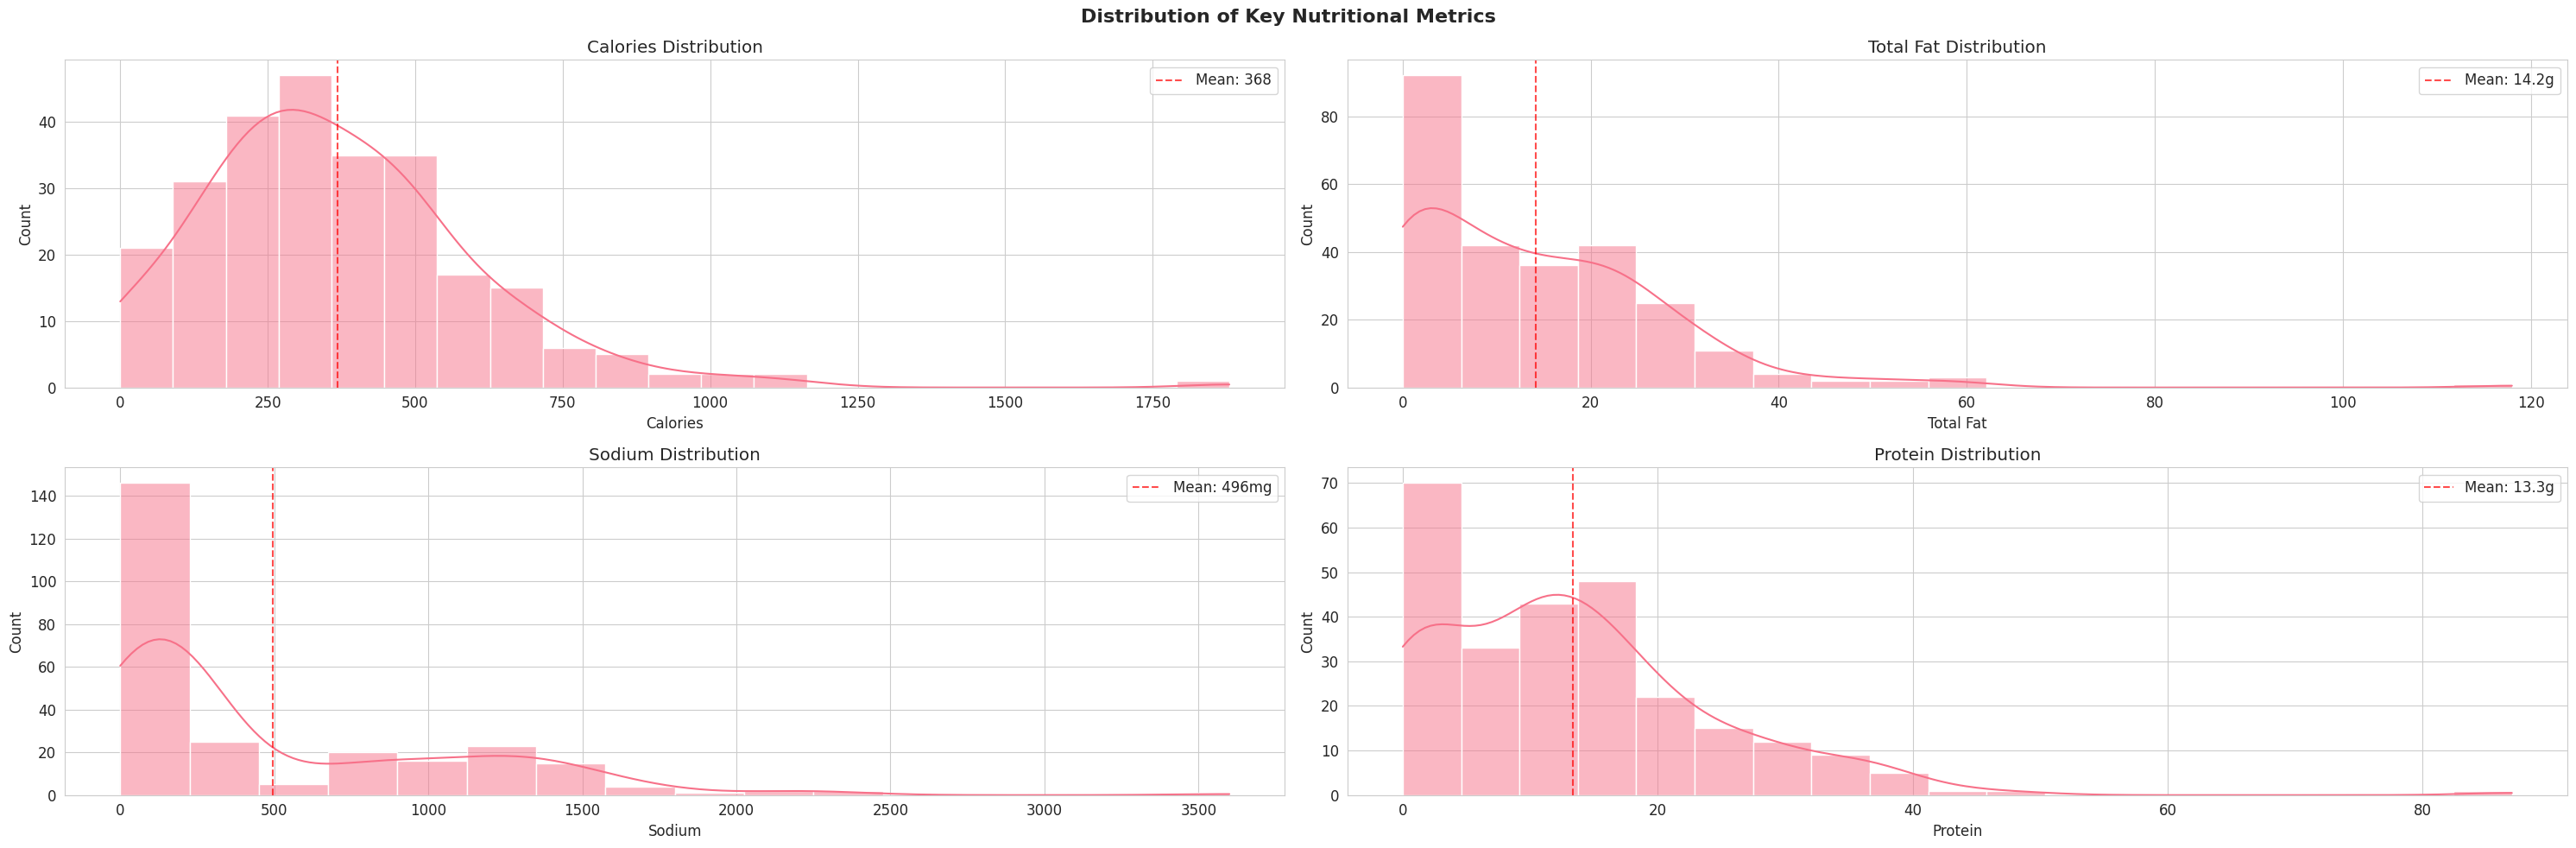

In [6]:
# Create a figure with multiple subplots for key nutritional metrics
fig, axes = plt.subplots(2, 2, figsize=(30, 10))
fig.suptitle('Distribution of Key Nutritional Metrics', fontsize=16, fontweight='bold')

# Calories distribution
sns.histplot(data=df, x='Calories', kde=True, ax=axes[0,0])
axes[0,0].set_title('Calories Distribution')
axes[0,0].axvline(df['Calories'].mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean: {df["Calories"].mean():.0f}')
axes[0,0].legend()

# Total Fat distribution
sns.histplot(data=df, x='Total Fat', kde=True, ax=axes[0,1])
axes[0,1].set_title('Total Fat Distribution')
axes[0,1].axvline(df['Total Fat'].mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean: {df["Total Fat"].mean():.1f}g')
axes[0,1].legend()

# Sodium distribution
sns.histplot(data=df, x='Sodium', kde=True, ax=axes[1,0])
axes[1,0].set_title('Sodium Distribution')
axes[1,0].axvline(df['Sodium'].mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean: {df["Sodium"].mean():.0f}mg')
axes[1,0].legend()

# Protein distribution
sns.histplot(data=df, x='Protein', kde=True, ax=axes[1,1])
axes[1,1].set_title('Protein Distribution')
axes[1,1].axvline(df['Protein'].mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean: {df["Protein"].mean():.1f}g')
axes[1,1].legend()

plt.tight_layout()
plt.show()

## Category analysis

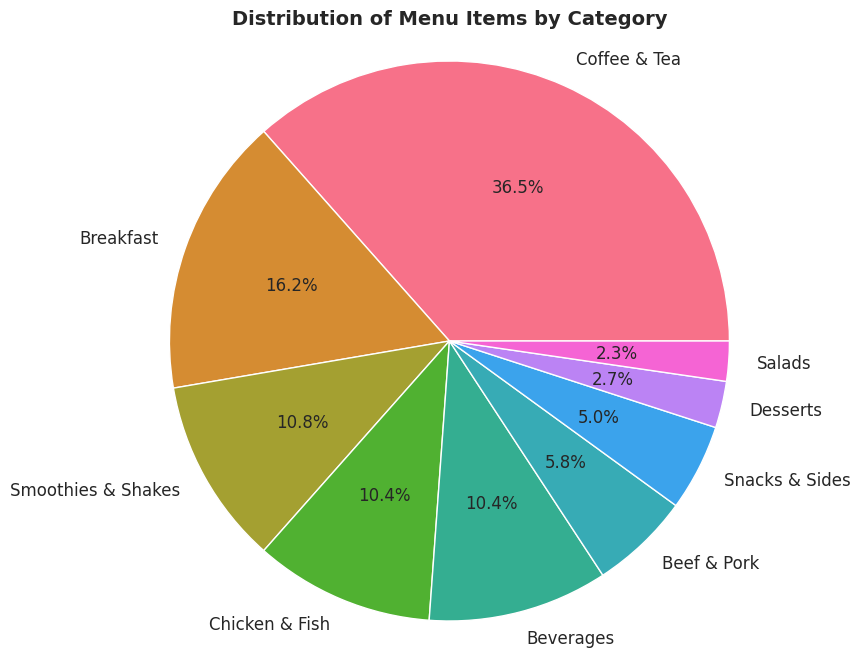

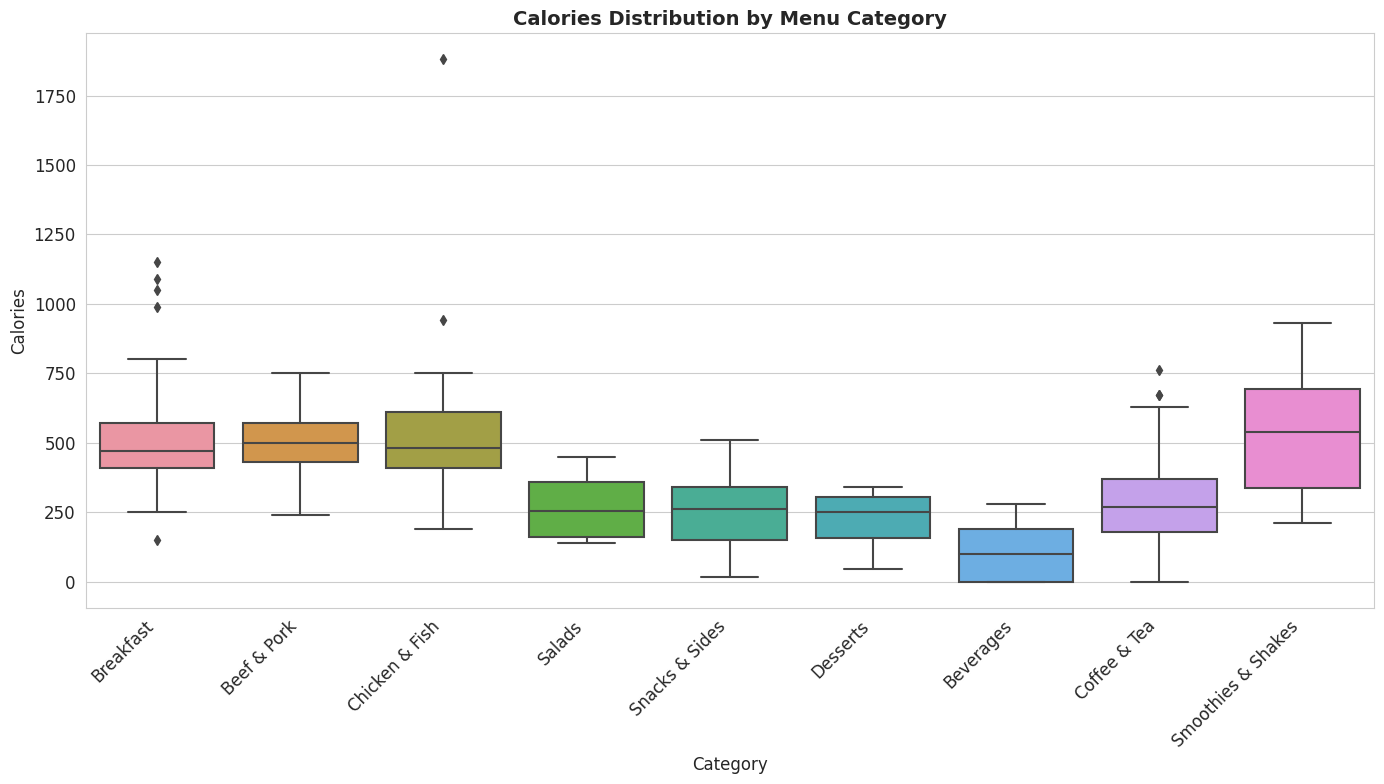

In [7]:
plt.figure(figsize=(10, 8))
colors = sns.color_palette("husl", len(category_counts))
plt.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', colors=colors)
plt.title('Distribution of Menu Items by Category', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

# Box plots for calories by category
plt.figure(figsize=(14, 8))
sns.boxplot(data=df, x='Category', y='Calories')
plt.title('Calories Distribution by Menu Category', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Correlation analysis

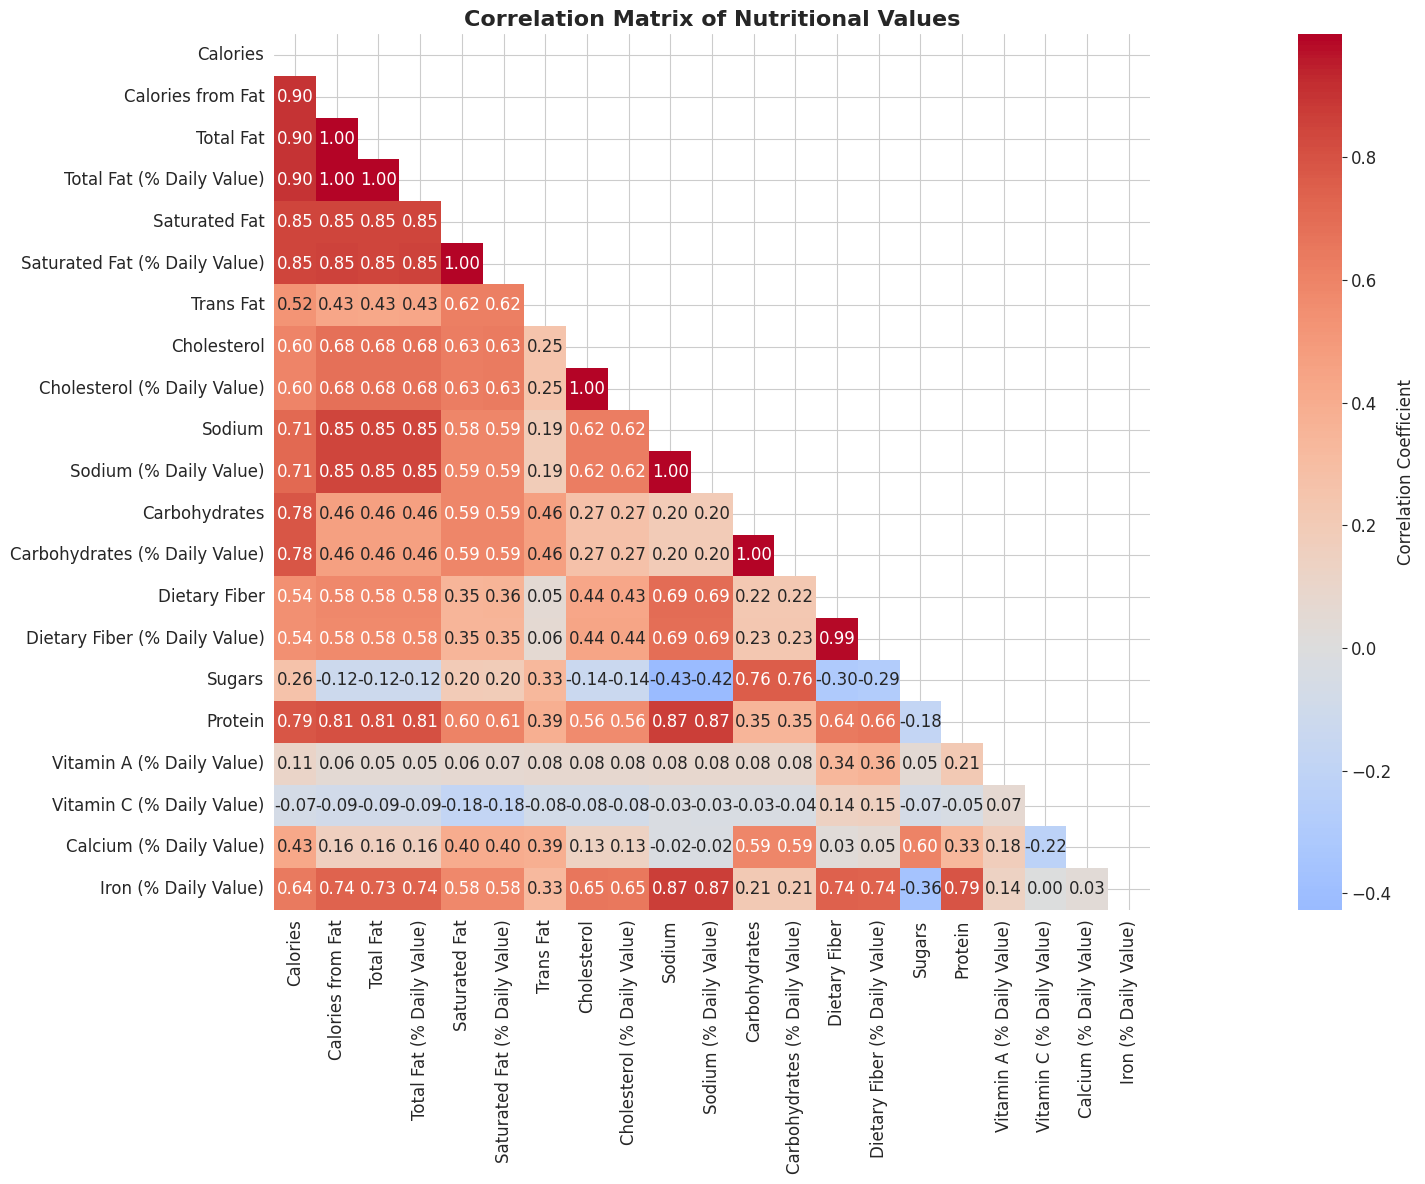

In [8]:
# Select numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numerical_cols].corr()

# Create correlation heatmap
plt.figure(figsize=(30, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.2f',
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix of Nutritional Values', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Scatter plot

<Figure size 1500x1500 with 0 Axes>

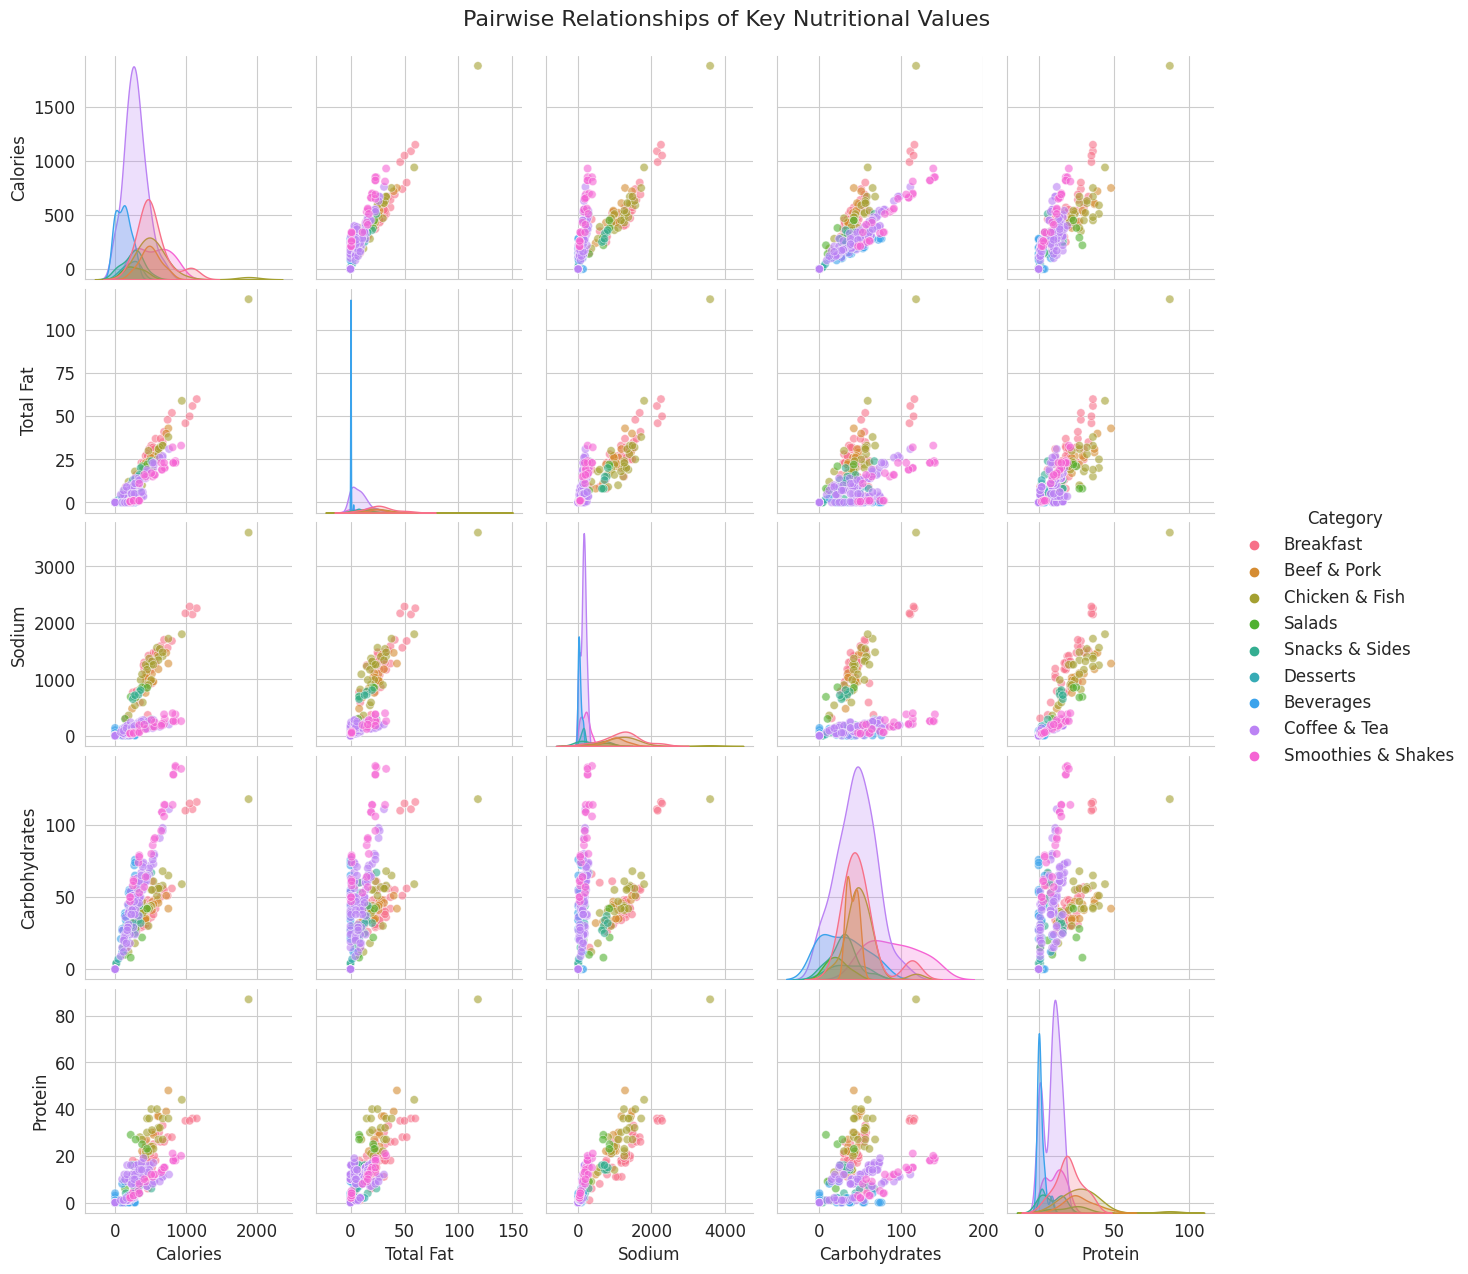

In [9]:
# Create scatter plot matrix for key nutrients
key_nutrients = ['Calories', 'Total Fat', 'Sodium', 'Carbohydrates', 'Protein']
df_key = df[key_nutrients + ['Category']]

# Pairplot with categories
plt.figure(figsize=(15, 15))
g = sns.pairplot(df_key, hue='Category', diag_kind='kde', plot_kws={'alpha': 0.6})
g.fig.suptitle('Pairwise Relationships of Key Nutritional Values', y=1.02, fontsize=16)
plt.show()

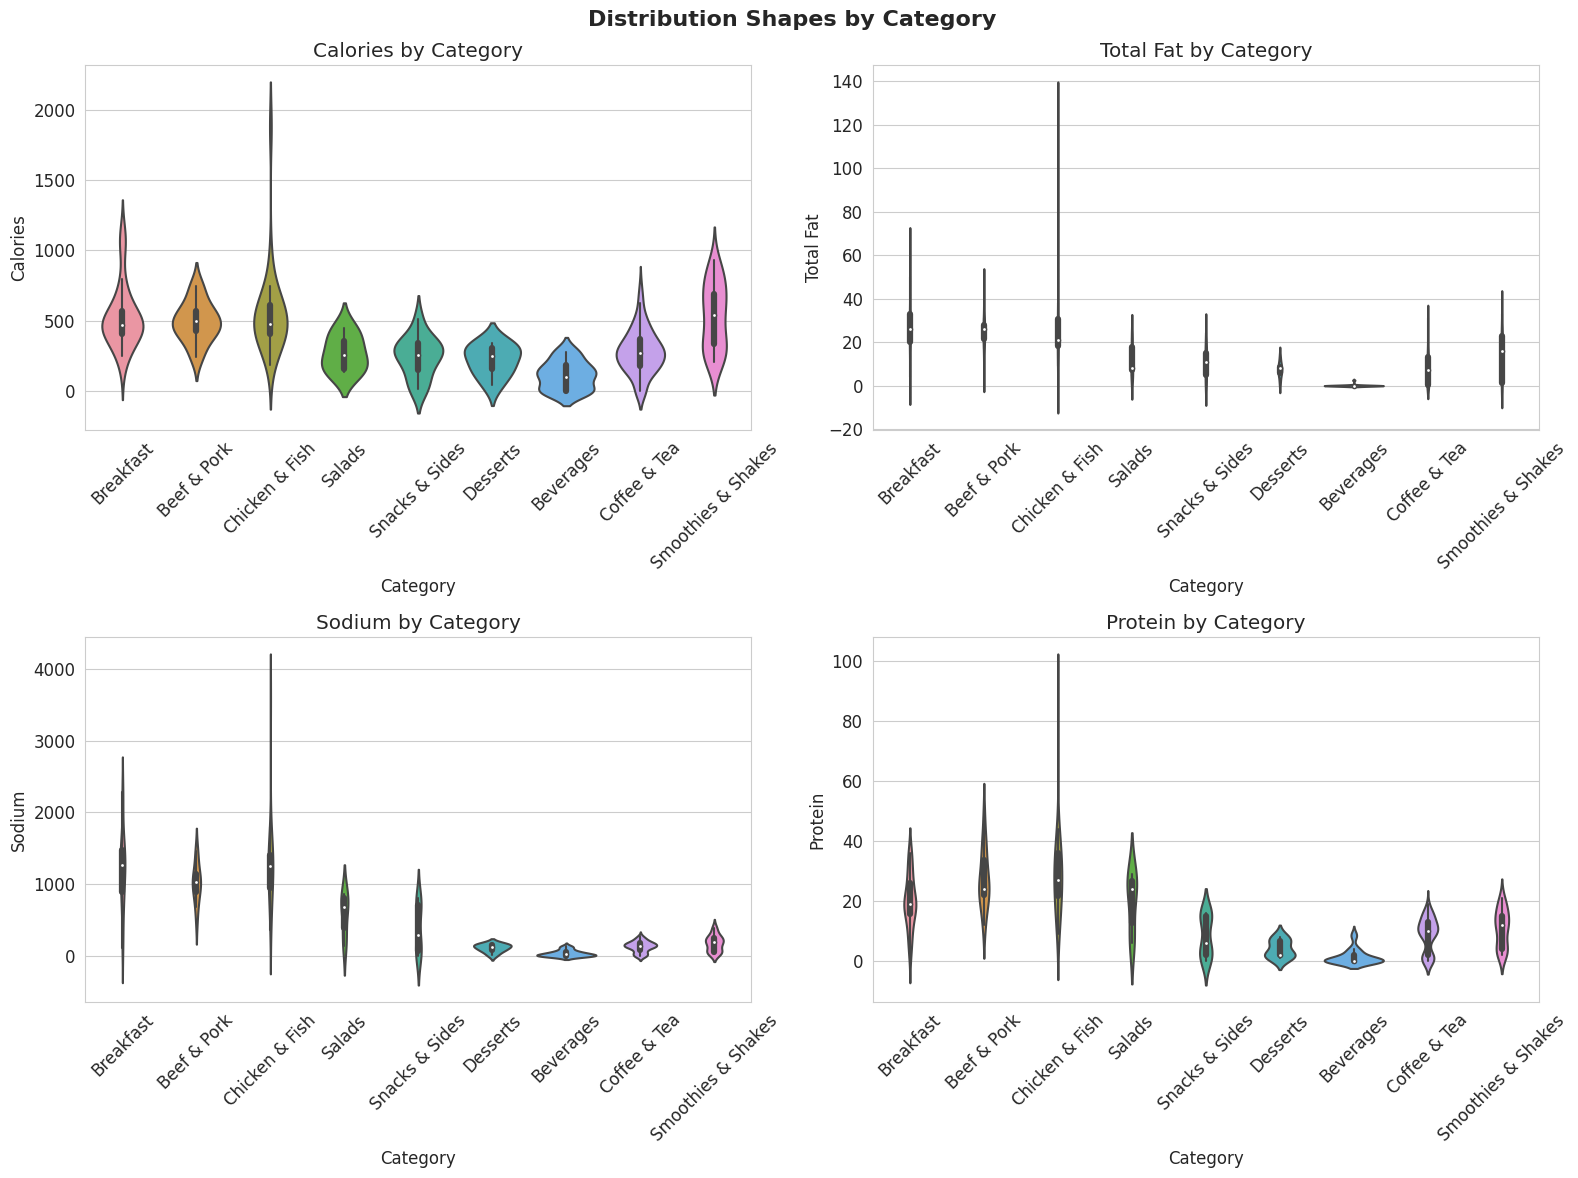

In [10]:
# Create violin plots for key metrics by category
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribution Shapes by Category', fontsize=16, fontweight='bold')

# Calories violin plot
sns.violinplot(data=df, x='Category', y='Calories', ax=axes[0,0])
axes[0,0].set_title('Calories by Category')
axes[0,0].tick_params(axis='x', rotation=45)

# Total Fat violin plot
sns.violinplot(data=df, x='Category', y='Total Fat', ax=axes[0,1])
axes[0,1].set_title('Total Fat by Category')
axes[0,1].tick_params(axis='x', rotation=45)

# Sodium violin plot
sns.violinplot(data=df, x='Category', y='Sodium', ax=axes[1,0])
axes[1,0].set_title('Sodium by Category')
axes[1,0].tick_params(axis='x', rotation=45)

# Protein violin plot
sns.violinplot(data=df, x='Category', y='Protein', ax=axes[1,1])
axes[1,1].set_title('Protein by Category')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Regression analysis

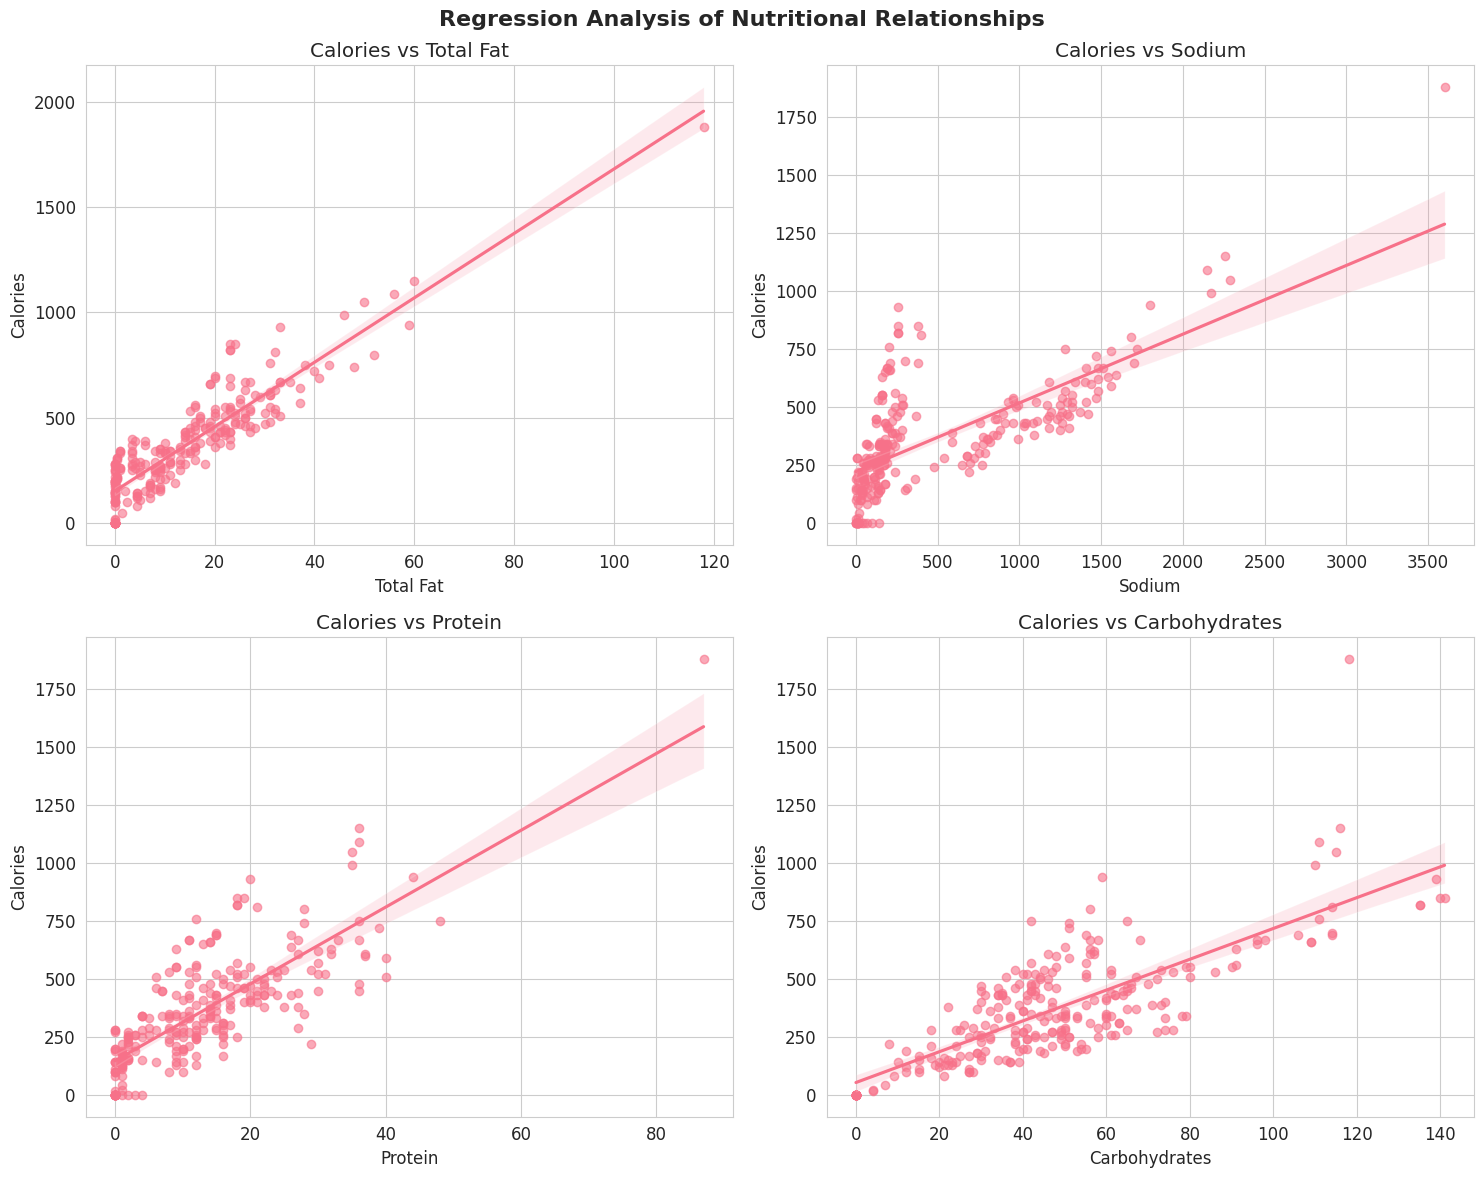

In [11]:
# Create regression plots for interesting relationships
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Regression Analysis of Nutritional Relationships', fontsize=16, fontweight='bold')

# Calories vs Total Fat
sns.regplot(data=df, x='Total Fat', y='Calories', ax=axes[0,0], scatter_kws={'alpha': 0.6})
axes[0,0].set_title('Calories vs Total Fat')

# Calories vs Sodium
sns.regplot(data=df, x='Sodium', y='Calories', ax=axes[0,1], scatter_kws={'alpha': 0.6})
axes[0,1].set_title('Calories vs Sodium')

# Calories vs Protein
sns.regplot(data=df, x='Protein', y='Calories', ax=axes[1,0], scatter_kws={'alpha': 0.6})
axes[1,0].set_title('Calories vs Protein')

# Calories vs Carbohydrates
sns.regplot(data=df, x='Carbohydrates', y='Calories', ax=axes[1,1], scatter_kws={'alpha': 0.6})
axes[1,1].set_title('Calories vs Carbohydrates')

plt.tight_layout()
plt.show()

In [12]:
# Calculate correlation coefficients
print("\n🔍 Key Correlation Coefficients:")
key_correlations = [
    ('Calories', 'Total Fat'),
    ('Calories', 'Sodium'),
    ('Calories', 'Protein'),
    ('Calories', 'Carbohydrates'),
    ('Total Fat', 'Saturated Fat'),
    ('Sodium', 'Calories from Fat')
]

for var1, var2 in key_correlations:
    corr_coef, p_value = pearsonr(df[var1], df[var2])
    print(f"{var1} vs {var2}: r = {corr_coef:.3f}, p = {p_value:.3f}")

# Category-wise statistics
print("\n🔍 Category-wise Statistics:")
category_stats = df.groupby('Category').agg({
    'Calories': ['mean', 'std', 'min', 'max'],
    'Total Fat': ['mean', 'std'],
    'Sodium': ['mean', 'std'],
    'Protein': ['mean', 'std']
}).round(2)

print(category_stats)


🔍 Key Correlation Coefficients:
Calories vs Total Fat: r = 0.904, p = 0.000
Calories vs Sodium: r = 0.712, p = 0.000
Calories vs Protein: r = 0.788, p = 0.000
Calories vs Carbohydrates: r = 0.782, p = 0.000
Total Fat vs Saturated Fat: r = 0.847, p = 0.000
Sodium vs Calories from Fat: r = 0.847, p = 0.000

🔍 Category-wise Statistics:
                   Calories                    Total Fat          Sodium  \
                       mean     std  min   max      mean    std     mean   
Category                                                                   
Beef & Pork          494.00  141.36  240   750     24.87   9.25  1020.67   
Beverages            113.70   99.19    0   280      0.09   0.48    41.48   
Breakfast            526.67  221.68  150  1150     27.69  13.34  1211.07   
Chicken & Fish       552.96  306.54  190  1880     26.96  20.86  1257.78   
Coffee & Tea         283.89  157.81    0   760      8.02   7.44   136.89   
Desserts             222.14  108.08   45   340      7.36

## Heatmaps for category insights

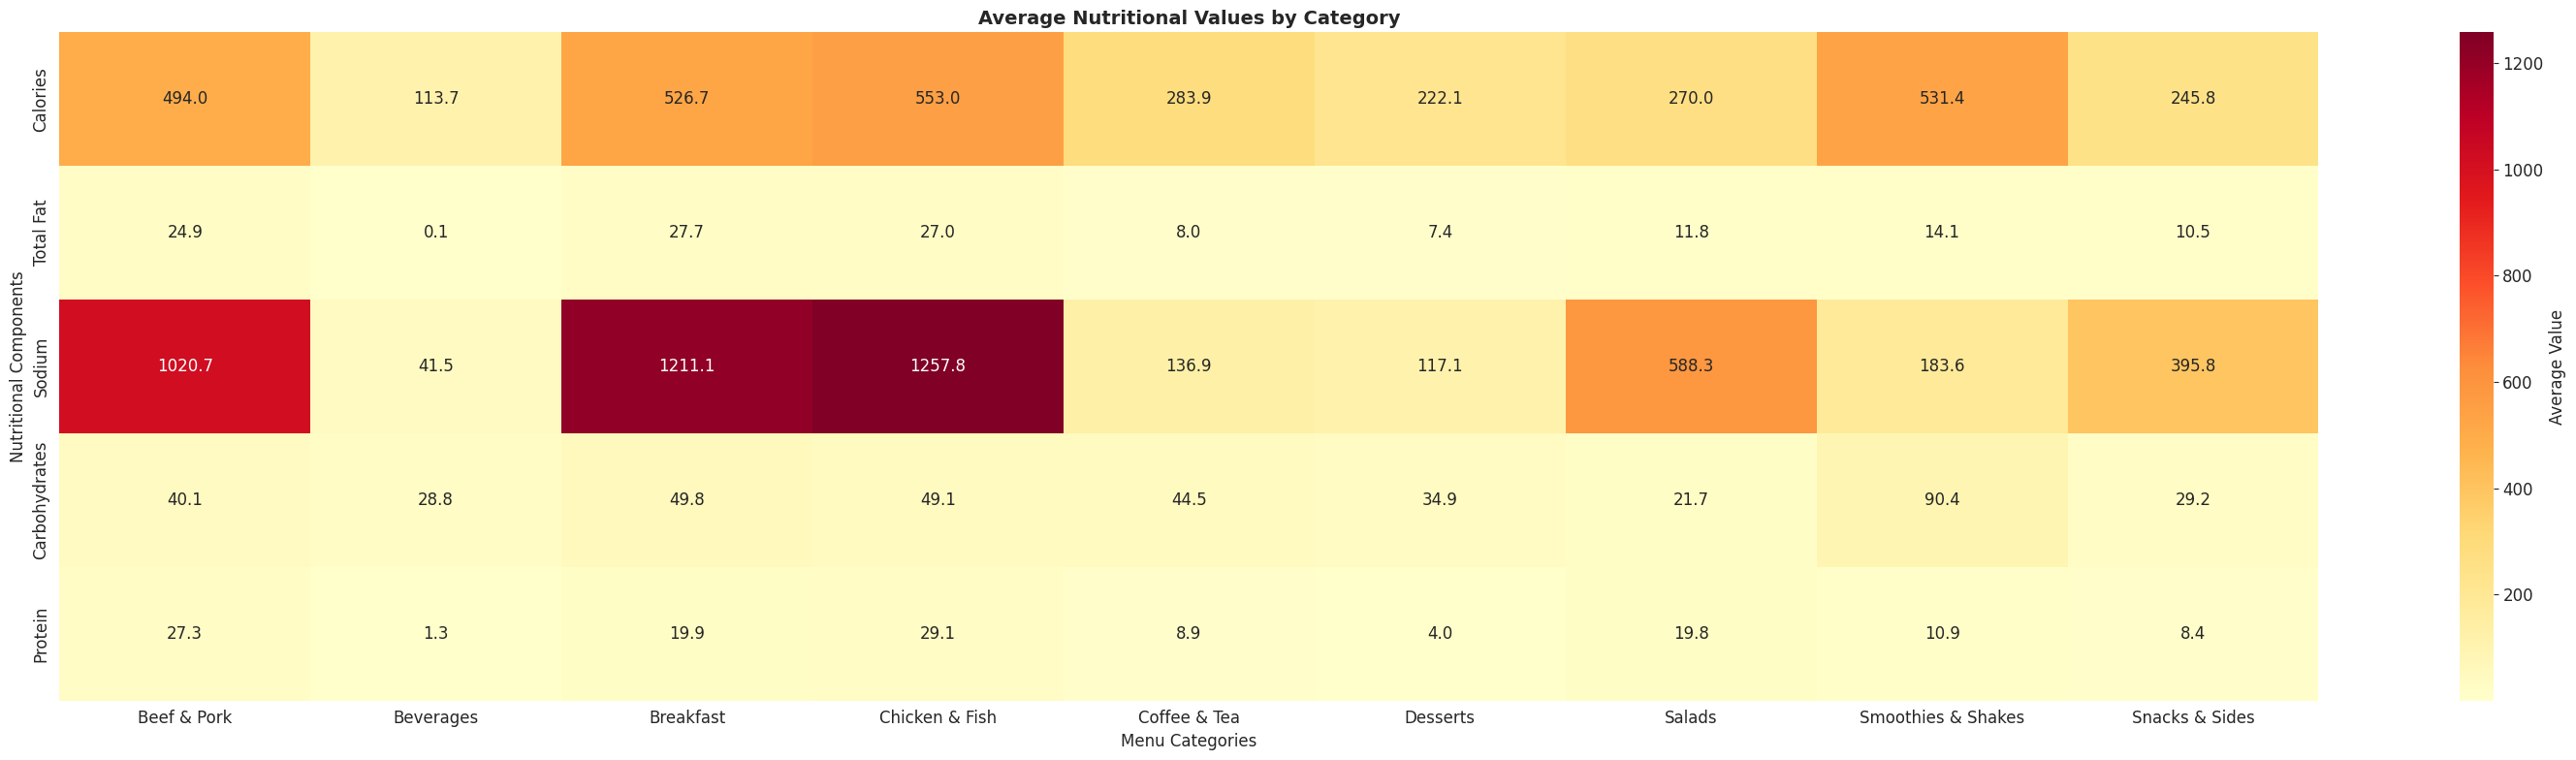

In [13]:
# Create a heatmap showing average nutritional values by category
category_means = df.groupby('Category')[key_nutrients].mean()

plt.figure(figsize=(30, 8))
sns.heatmap(category_means.T, 
            annot=True, 
            cmap='YlOrRd', 
            fmt='.1f',
            cbar_kws={'label': 'Average Value'})
plt.title('Average Nutritional Values by Category', fontsize=14, fontweight='bold')
plt.ylabel('Nutritional Components')
plt.xlabel('Menu Categories')
plt.tight_layout()
plt.show()

## Outlier detection 

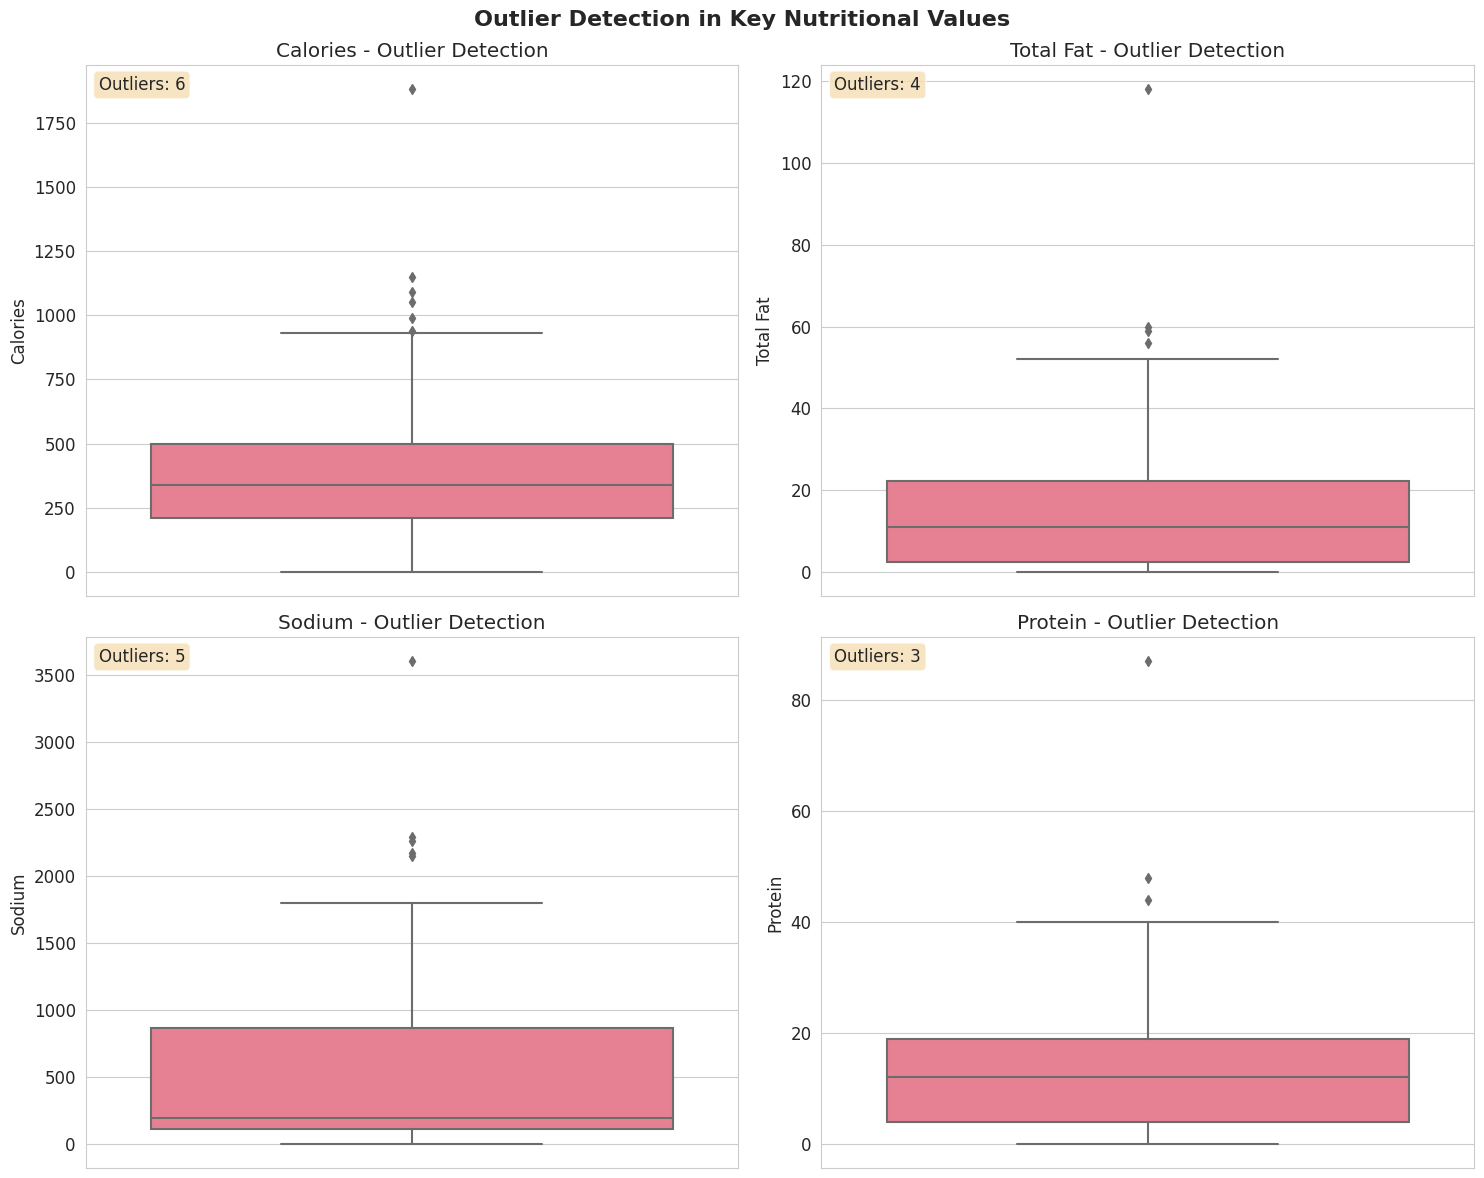

In [14]:
# Create box plots to identify outliers
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Outlier Detection in Key Nutritional Values', fontsize=16, fontweight='bold')

# Box plots for outlier detection
nutrients_to_check = ['Calories', 'Total Fat', 'Sodium', 'Protein']

for i, nutrient in enumerate(nutrients_to_check):
    row = i // 2
    col = i % 2
    sns.boxplot(data=df, y=nutrient, ax=axes[row, col])
    axes[row, col].set_title(f'{nutrient} - Outlier Detection')
    
    # Calculate and display outlier statistics
    Q1 = df[nutrient].quantile(0.25)
    Q3 = df[nutrient].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[nutrient] < lower_bound) | (df[nutrient] > upper_bound)]
    axes[row, col].text(0.02, 0.98, f'Outliers: {len(outliers)}', 
                       transform=axes[row, col].transAxes, 
                       verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

## Comparative analysis

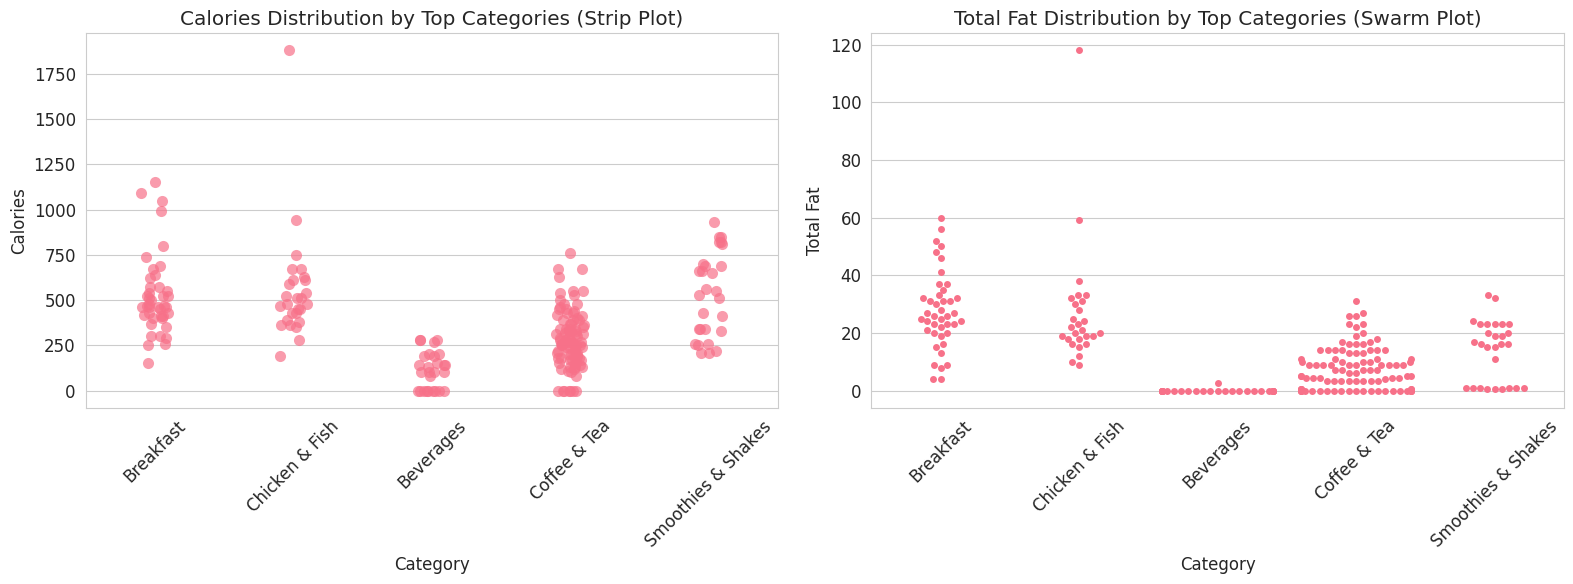

In [15]:
# Create a radar chart-style comparison (using polar coordinates)
from math import pi

# Select top categories by item count
top_categories = df['Category'].value_counts().head(5).index
df_top = df[df['Category'].isin(top_categories)]

# Create a figure with subplots for comparative analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Strip plot for detailed comparison
sns.stripplot(data=df_top, x='Category', y='Calories', size=8, alpha=0.7, ax=axes[0])
axes[0].set_title('Calories Distribution by Top Categories (Strip Plot)')
axes[0].tick_params(axis='x', rotation=45)

# Swarm plot for another perspective
sns.swarmplot(data=df_top, x='Category', y='Total Fat', size=5, ax=axes[1])
axes[1].set_title('Total Fat Distribution by Top Categories (Swarm Plot)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Key insights

In [16]:
# Calculate some key insights
highest_calorie_item = df.loc[df['Calories'].idxmax()]
lowest_calorie_item = df.loc[df['Calories'].idxmin()]
highest_sodium_item = df.loc[df['Sodium'].idxmax()]
highest_protein_item = df.loc[df['Protein'].idxmax()]

print(f"\n🔍 Key Findings:")
print(f"• Highest Calorie Item: {highest_calorie_item['Item']} ({highest_calorie_item['Calories']} calories)")
print(f"• Lowest Calorie Item: {lowest_calorie_item['Item']} ({lowest_calorie_item['Calories']} calories)")
print(f"• Highest Sodium Item: {highest_sodium_item['Item']} ({highest_sodium_item['Sodium']}mg sodium)")
print(f"• Highest Protein Item: {highest_protein_item['Item']} ({highest_protein_item['Protein']}g protein)")

# Category insights
print(f"\n📊 Category Insights:")
category_calorie_means = df.groupby('Category')['Calories'].mean().sort_values(ascending=False)
print(f"• Highest Average Calories: {category_calorie_means.index[0]} ({category_calorie_means.iloc[0]:.0f} calories)")
print(f"• Lowest Average Calories: {category_calorie_means.index[-1]} ({category_calorie_means.iloc[-1]:.0f} calories)")

# Correlation insights
calories_fat_corr = df['Calories'].corr(df['Total Fat'])
calories_sodium_corr = df['Calories'].corr(df['Sodium'])
print(f"\n🔗 Correlation Insights:")
print(f"• Calories-Fat Correlation: {calories_fat_corr:.3f}")
print(f"• Calories-Sodium Correlation: {calories_sodium_corr:.3f}")


🔍 Key Findings:
• Highest Calorie Item: Chicken McNuggets (40 piece) (1880 calories)
• Lowest Calorie Item: Diet Coke (Small) (0 calories)
• Highest Sodium Item: Chicken McNuggets (40 piece) (3600mg sodium)
• Highest Protein Item: Chicken McNuggets (40 piece) (87g protein)

📊 Category Insights:
• Highest Average Calories: Chicken & Fish (553 calories)
• Lowest Average Calories: Beverages (114 calories)

🔗 Correlation Insights:
• Calories-Fat Correlation: 0.904
• Calories-Sodium Correlation: 0.712


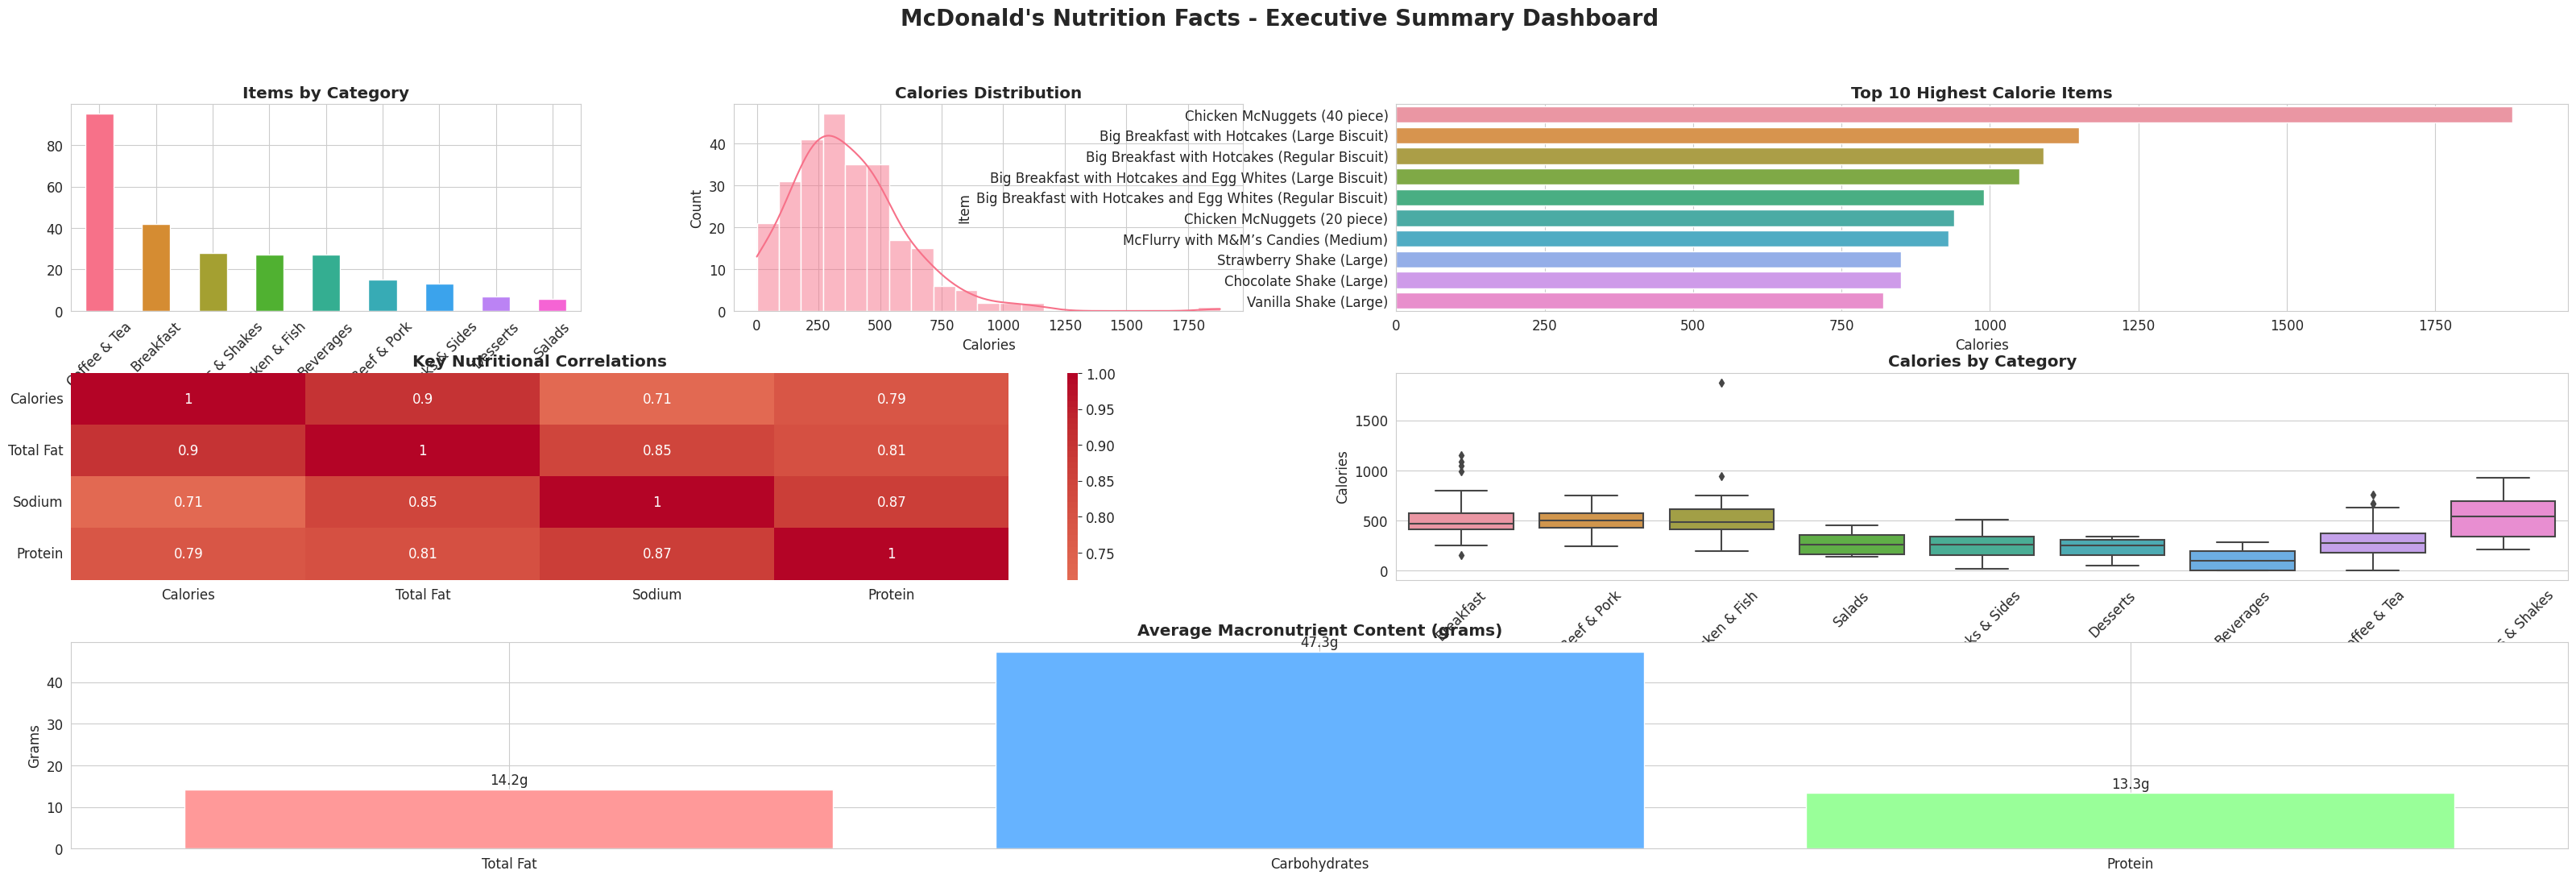

In [17]:
# Create a comprehensive summary dashboard
fig = plt.figure(figsize=(40, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# 1. Category distribution
ax1 = fig.add_subplot(gs[0, 0])
category_counts.plot(kind='bar', ax=ax1, color=sns.color_palette("husl", len(category_counts)))
ax1.set_title('Items by Category', fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

# 2. Calories distribution
ax2 = fig.add_subplot(gs[0, 1])
sns.histplot(data=df, x='Calories', kde=True, ax=ax2)
ax2.set_title('Calories Distribution', fontweight='bold')

# 3. Top 10 highest calorie items
ax3 = fig.add_subplot(gs[0, 2:])
top_calorie_items = df.nlargest(10, 'Calories')
sns.barplot(data=top_calorie_items, x='Calories', y='Item', ax=ax3)
ax3.set_title('Top 10 Highest Calorie Items', fontweight='bold')

# 4. Nutritional correlation
ax4 = fig.add_subplot(gs[1, :2])
key_corr = df[['Calories', 'Total Fat', 'Sodium', 'Protein']].corr()
sns.heatmap(key_corr, annot=True, cmap='coolwarm', center=0, ax=ax4)
ax4.set_title('Key Nutritional Correlations', fontweight='bold')

# 5. Category-wise calories
ax5 = fig.add_subplot(gs[1, 2:])
sns.boxplot(data=df, x='Category', y='Calories', ax=ax5)
ax5.set_title('Calories by Category', fontweight='bold')
ax5.tick_params(axis='x', rotation=45)

# 6. Macronutrient breakdown
ax6 = fig.add_subplot(gs[2, :])
macronutrients = ['Total Fat', 'Carbohydrates', 'Protein']
avg_macros = df[macronutrients].mean()
colors = ['#ff9999', '#66b3ff', '#99ff99']
bars = ax6.bar(macronutrients, avg_macros, color=colors)
ax6.set_title('Average Macronutrient Content (grams)', fontweight='bold')
ax6.set_ylabel('Grams')

# Add value labels on bars
for bar, value in zip(bars, avg_macros):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{value:.1f}g', ha='center', va='bottom')

plt.suptitle('McDonald\'s Nutrition Facts - Executive Summary Dashboard', 
             fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()